In [11]:
#code to create unique occupied states plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec

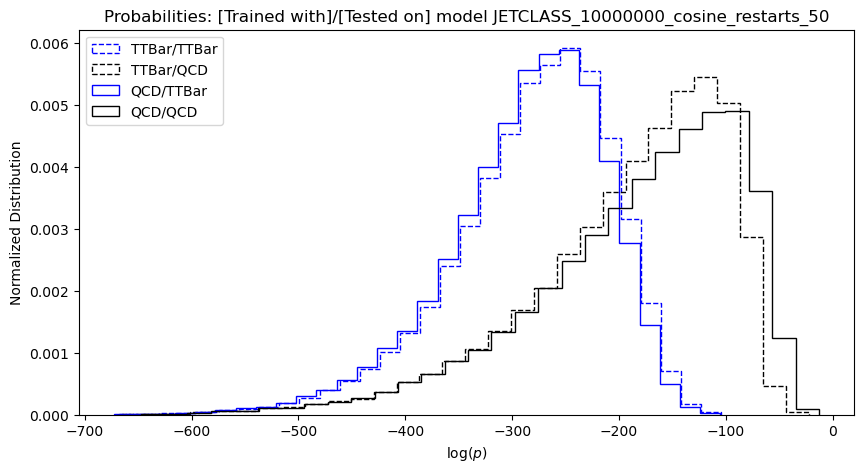

In [12]:
# [trained_on]_[data_from]
DATASET = "JETCLASS"

#epochs = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20 ,22, 24 ,26, 28]
epochs = [2]
folder = f"{DATASET}_10000000_cosine_restarts_50"

classes = ["TTBar", "QCD"]
colors = ["blue", "black"]
lines = ["--", "-"]
    
tag = "test"

fig, ax = plt.subplots(figsize=(10, 5))

bins = 30
for k in range(len(epochs)):
    for i in range(len(classes)):
        for j in range(len(classes)):
            # normalized histogram (area = 1), step style
            data = pd.read_csv(f"../output/evaluation/{folder}/epoch_{epochs[k]}/{tag}/{classes[i]}_{classes[j]}_{tag}.csv")

            ax.hist(
                data["probs"],
                bins=bins,                 # adjust for smoothness
                density=True,            # normalization
                histtype="step",
                linewidth=1.0,
                linestyle=lines[i],
                color=colors[j],
                label=f"{classes[i]}/{classes[j]}"
            )


ax.set_ylabel("Normalized Distribution")
ax.set_xlabel(r"$\log(p)$")

ax.set_title(f"Probabilities: [Trained with]/[Tested on] model {folder}")

ax.legend()

plt.show()